# Load the dataset

In [1]:
import os
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import anndata as ad
import scanpy as sc


In [ ]:
os.chdir('c:\\Users\\31904\\Desktop\\eTFAST\\')
adata = ad.read("data/processed/3mouse_coronal_hemibrain/mousebrain_bin60_clustered.h5ad")
adata


AnnData object with n_obs × n_vars = 7765 × 21667
    obs: 'area', 'n_counts', 'Size_Factor', 'initial_cell_size', 'louvain', 'scc', 'scc_anno'
    var: 'pass_basic_filter'
    uns: '__type', 'louvain', 'louvain_colors', 'neighbors', 'pp', 'scc', 'scc_anno_colors', 'scc_colors', 'spatial', 'spatial_neighbors'
    obsm: 'X_pca', 'X_spatial', 'bbox', 'contour', 'spatial'
    layers: 'count', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [14]:
adata.obsm['X_spatial']

array([[ 630., 2490.],
       [ 630., 2550.],
       [ 630., 2610.],
       ...,
       [5970., 5430.],
       [5970., 5490.],
       [5970., 5550.]])

In [5]:
print("\n细胞类型信息：")
print(adata.obs['scc_anno'].value_counts())


细胞类型信息：
scc_anno
Isocortex L6      716
Fiber tracts      703
DORpm             668
AMY               635
Isocortex L5      582
HY                565
DORsm             559
HIP & CTXpl L1    508
Isocortex L2/3    476
STRd              457
CTXsp             436
PAL               406
Isocortex L4      346
OLF               227
DG                196
CA                123
RT                 91
VS                 71
Name: count, dtype: int64


In [3]:
adata.X

<7765x21667 sparse matrix of type '<class 'numpy.float32'>'
	with 7767934 stored elements in Compressed Sparse Row format>

In [5]:
# 转换为 DataFrame，保留细胞名称作为索引
coord_df = pd.DataFrame(
    adata.obsm['spatial'],
    index=adata.obs.index,  # 细胞名作为行名
    columns=['coord_x', 'coord_y']  # 列名自定义
)
coord_df.to_csv('./data/processed/3mouse_coronal_hemibrain/hemibrain_original_cell_coordinates.csv')

In [6]:
adata.obs['cell_type'] = adata.obs['scc_anno'].astype('category')
adata.obs['cell_type'].value_counts()

cell_type
Isocortex L6      716
Fiber tracts      703
DORpm             668
AMY               635
Isocortex L5      582
HY                565
DORsm             559
HIP & CTXpl L1    508
Isocortex L2/3    476
STRd              457
CTXsp             436
PAL               406
Isocortex L4      346
OLF               227
DG                196
CA                123
RT                 91
VS                 71
Name: count, dtype: int64

# QC

d:\app\anaconda\envs\tf_env\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


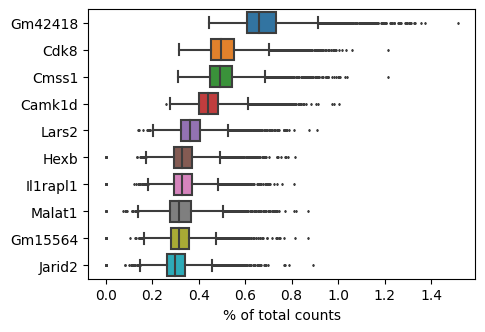

AnnData object with n_obs × n_vars = 7745 × 21666
    obs: 'area', 'n_counts', 'Size_Factor', 'initial_cell_size', 'louvain', 'scc', 'scc_anno', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'pass_basic_filter', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: '__type', 'louvain', 'neighbors', 'pp', 'scc', 'spatial', 'spatial_neighbors', 'log1p'
    obsm: 'X_pca', 'X_spatial', 'bbox', 'contour', 'spatial'
    layers: 'count', 'spliced', 'unspliced', 'counts'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [7]:
# 质量控制（过滤低质量点）
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

# 选择高表达基因
sc.pl.highest_expr_genes(adata,n_top=10)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 标准化和降维
adata.layers["counts"]= adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata





In [ ]:
adata.obs['scc_anno']

d:\app\anaconda\envs\tf_env\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


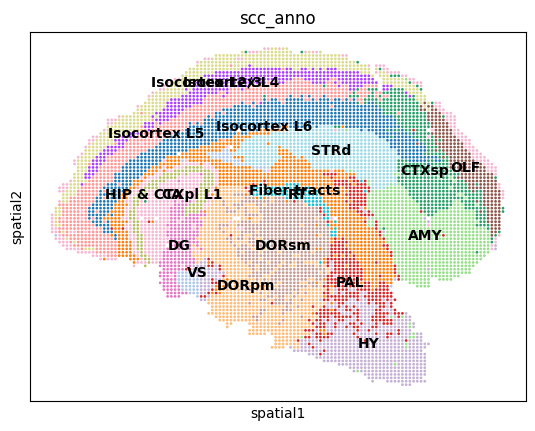

In [8]:
sc.pl.embedding(adata, basis="spatial", color=["scc_anno"], legend_loc="on data")

In [18]:
adata.var_names = adata.var_names.str.upper()
adata.write('./data/processed/3mouse_coronal_hemibrain/mousebrain_bin60_clustered_processed.h5ad')


In [7]:
adata.write('./data/processed/3mouse_coronal_hemibrain/hemibrain_original.h5ad')